# CASE 3: 1D Heat Diffusion Equation with Mixed Boundary Conditions (No Source Term)

## Governing Equation

∂y/∂t = ∂²y/∂x²

## Boundary Conditions

Left Boundary (Dirichlet)

y(0) = 1

Right Boundary (Neumann)

dy/dx (1) = 0

## Initial Condition

y(x,0) = sin(πx)

## Objective

To study the transient and steady-state behaviour of the one-dimensional heat diffusion equation under mixed boundary conditions using the finite volume method implemented in FiPy.

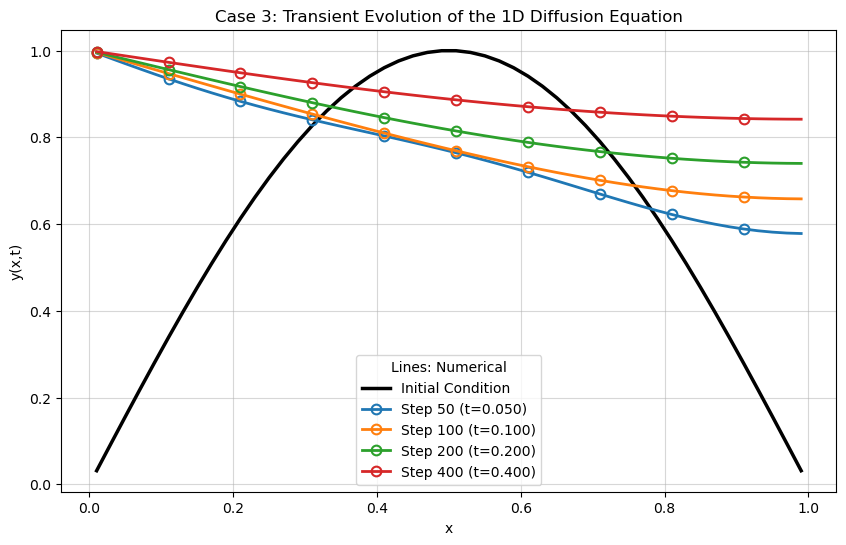

In [2]:
# =====================================================
# CASE 3 : NEUMANN BC WITHOUT SOURCE TERM
# TRANSIENT STUDY
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

dt = 1e-3

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

initial_profile = np.sin(np.pi * x)

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=initial_profile
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

phi.constrain(1.0, mesh.facesLeft)              # y(0)=1
phi.faceGrad.constrain([0.0], mesh.facesRight)  # dy/dx(1)=0

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
)

# =====================================================
# TRANSIENT EVOLUTION
# =====================================================

times = [50, 100, 200, 400]
solutions = []

for step in range(1, 401):

    eq.solve(var=phi, dt=dt)

    if step in times:
        solutions.append(np.array(phi.value))

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# Initial Condition

plt.plot(
    x,
    initial_profile,
    color='black',
    linewidth=2.5,
    label='Initial Condition'
)

# Transient Solutions

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red'
]

for sol, step, color in zip(
    solutions,
    times,
    colors
):

    plt.plot(
        x,
        sol,
        color=color,
        linewidth=2,
        marker='o',
        markersize=7,
        markevery=5,
        fillstyle='none',
        markeredgewidth=1.5,
        label=f"Step {step} (t={step*dt:.3f})"
    )

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 3: Transient Evolution of the 1D Diffusion Equation"
)

plt.xlabel("x")
plt.ylabel("y(x,t)")

plt.grid(True, alpha=0.5)

plt.legend(
    title="Lines: Numerical",
    loc='best'
)

plt.savefig(
    "Case3_Transient_Evolution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

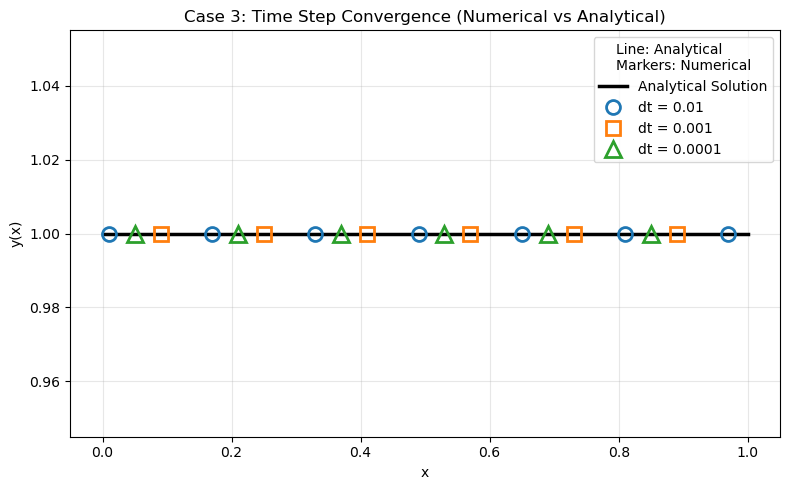

In [6]:
# ==================================================
# CASE 3 : TIME STEP CONVERGENCE
# NUMERICAL vs ANALYTICAL
# ==================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 50
dx = L / nx

dt_values = [0.01, 0.001, 0.0001]

# Must remain fixed for timestep convergence
final_time = 5.0

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(
    nx=nx,
    dx=dx
)

x = np.array(mesh.cellCenters[0])

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_ref = np.linspace(0, 1, 500)

analytical = np.ones_like(x_ref)

# ==================================================
# STORE NUMERICAL SOLUTIONS
# ==================================================

solutions = []

for dt in dt_values:

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # ==============================================
    # BOUNDARY CONDITIONS
    # ==============================================

    phi.constrain(
        1.0,
        where=mesh.facesLeft
    )

    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesRight
    )

    # ==============================================
    # GOVERNING EQUATION
    # ==============================================

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
    )

    # ==============================================
    # TIME INTEGRATION
    # ==============================================

    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(
            var=phi,
            dt=dt
        )

    numerical = np.array(phi.value)

    # Remove tiny numerical noise
    numerical[np.abs(numerical - 1.0) < 1e-4] = 1.0

    solutions.append(numerical)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical Solution

plt.plot(
    x_ref,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# ==================================================
# dt = 0.01
# ==================================================

idx1 = np.array([
    0, 8, 16, 24, 32, 40, 48
])

plt.plot(
    x[idx1],
    solutions[0][idx1],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2,
    label='dt = 0.01'
)

# ==================================================
# dt = 0.001
# ==================================================

idx2 = np.array([
    4, 12, 20, 28, 36, 44
])

plt.plot(
    x[idx2],
    solutions[1][idx2],
    linestyle='None',
    marker='s',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2,
    label='dt = 0.001'
)

# ==================================================
# dt = 0.0001
# ==================================================

idx3 = np.array([
    2, 10, 18, 26, 34, 42
])

plt.plot(
    x[idx3],
    solutions[2][idx3],
    linestyle='None',
    marker='^',
    markersize=11,
    markerfacecolor='none',
    markeredgewidth=2,
    label='dt = 0.0001'
)

# ==================================================
# GRAPH SETTINGS
# ==================================================

plt.title(
    "Case 3: Time Step Convergence (Numerical vs Analytical)"
)

plt.xlabel("x")

plt.ylabel("y(x)")

plt.grid(
    True,
    alpha=0.3
)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='best'
)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case3_TimeStep_Convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

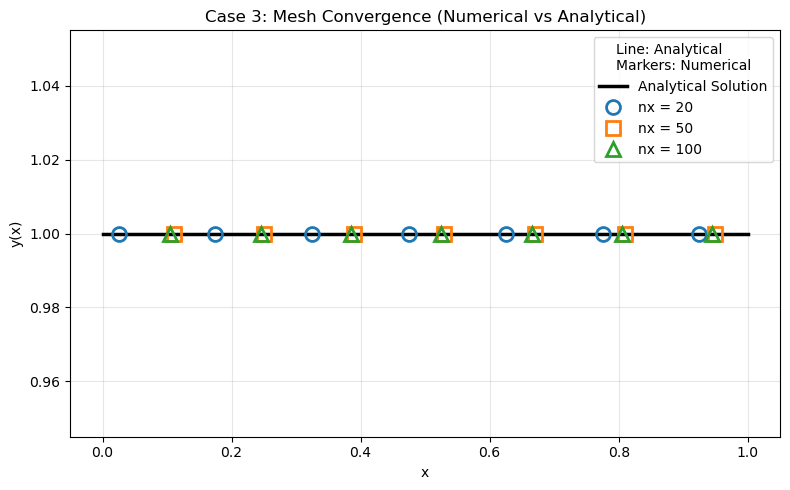

In [7]:
# =====================================================
# CASE 3 : MESH CONVERGENCE
# NUMERICAL vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
k = 1.0

mesh_sizes = [20, 50, 100]

plt.figure(figsize=(8, 5))

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_analytical = np.linspace(0, L, 500)

y_analytical = np.ones_like(x_analytical)

plt.plot(
    x_analytical,
    y_analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# =====================================================
# NUMERICAL SOLUTIONS
# =====================================================

markers = ['o', 's', '^']

for nx, marker in zip(mesh_sizes, markers):

    dx = L / nx

    mesh = Grid1D(
        dx=dx,
        nx=nx
    )

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions

    phi.constrain(
        1.0,
        where=mesh.facesLeft
    )

    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesRight
    )

    # Governing Equation

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
    )

    # =================================================
    # SOLVE TO STEADY STATE
    # =================================================

    dt = 1e-3
    tolerance = 1e-8

    residual = 1.0

    while residual > tolerance:

        old_phi = phi.value.copy()

        eq.solve(var=phi, dt=dt)

        residual = np.max(
            np.abs(phi.value - old_phi)
        )

    numerical = np.array(phi.value)

    # Remove tiny numerical noise

    numerical[np.abs(numerical - 1.0) < 1e-4] = 1.0

    # =================================================
    # MARKER SEPARATION
    # =================================================

    if nx == 20:

        idx = np.array([0, 3, 6, 9, 12, 15, 18])

    elif nx == 50:

        idx = np.array([5, 12, 19, 26, 33, 40, 47])

    else:

        idx = np.array([10, 24, 38, 52, 66, 80, 94])

    plt.plot(
        x[idx],
        numerical[idx],
        linestyle='None',
        marker=marker,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2,
        label=f'nx = {nx}'
    )

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.title(
    "Case 3: Mesh Convergence (Numerical vs Analytical)"
)

plt.xlabel("x")

plt.ylabel("y(x)")

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='best'
)

plt.tight_layout()

# =====================================================
# SAVE FIGURE
# =====================================================

plt.savefig(
    "Case3_Mesh_Convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== STEADY-STATE ANALYSIS ==========
Minimum Value = 1.0
Maximum Value = 1.0


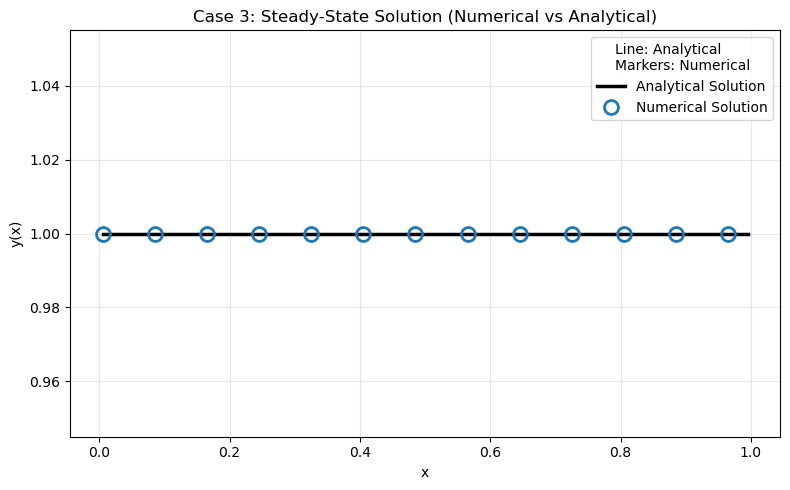

In [8]:
# =====================================================
# CASE 3 : STEADY-STATE SOLUTION
# NUMERICAL vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(
    nx=nx,
    dx=dx
)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

phi.constrain(
    1.0,
    where=mesh.facesLeft
)

phi.faceGrad.constrain(
    0.0,
    where=mesh.facesRight
)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
)

# =====================================================
# SOLVE TO STEADY STATE
# =====================================================

dt = 1e-3
tolerance = 1e-8

residual = 1.0

while residual > tolerance:

    old_phi = phi.value.copy()

    eq.solve(
        var=phi,
        dt=dt
    )

    residual = np.max(
        np.abs(phi.value - old_phi)
    )

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

numerical = np.array(phi.value)

# Remove tiny numerical noise

numerical[np.abs(numerical - 1.0) < 1e-4] = 1.0

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = np.ones_like(x)

# =====================================================
# RESULTS
# =====================================================

print("\n========== STEADY-STATE ANALYSIS ==========")
print("Minimum Value =", np.min(numerical))
print("Maximum Value =", np.max(numerical))

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical Solution

plt.plot(
    x,
    analytical,
    color='black',
    linewidth=2.5,
    label='Analytical Solution'
)

# =====================================================
# NUMERICAL MARKERS
# =====================================================

idx = np.array([
    0, 8, 16, 24, 32, 40,
    48, 56, 64, 72, 80, 88, 96
])

plt.plot(
    x[idx],
    numerical[idx],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2,
    label='Numerical Solution'
)

# =====================================================
# GRAPH SETTINGS
# =====================================================

plt.xlabel("x")

plt.ylabel("y(x)")

plt.title(
    "Case 3: Steady-State Solution (Numerical vs Analytical)"
)

plt.grid(
    True,
    alpha=0.3
)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='best'
)

plt.tight_layout()

# =====================================================
# SAVE FIGURE
# =====================================================

plt.savefig(
    "Case3_Steady_State_Comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Steady-State Analysis Observations

1. The transient solution converges to a constant temperature distribution throughout the domain.

2. The temperature remains uniform across the entire domain at steady state.

3. The Dirichlet boundary condition y(0) = 1 fixes the temperature level of the system.

4. The Neumann boundary condition dy/dx = 0 at x = 1 imposes zero temperature gradient at the right boundary.

5. The numerical steady-state solution is a horizontal line with temperature equal to 1.

6. The minimum and maximum numerical values are both approximately equal to 1, confirming convergence to the analytical solution.

7. The numerical and analytical steady-state solutions are in excellent agreement, with only negligible numerical error.

# =====================================================
# STEADY-STATE VERIFICATION
# =====================================================

The steady-state solution obtained at t = 10 is compared with the
solution obtained at t = 20.

If both profiles overlap, the solution is confirmed to have
reached steady state.

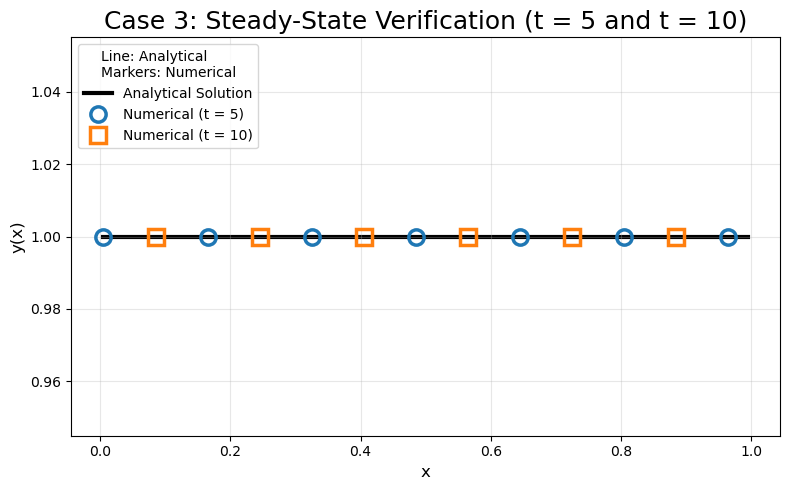


========== CASE 3 STEADY-STATE VERIFICATION ==========
Maximum Difference = 0.000000e+00


In [11]:
# =====================================================
# CASE 3 : STEADY-STATE VERIFICATION
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
)

dt = 1e-3

# =====================================================
# SOLUTION AT t = 5
# =====================================================

phi_t5 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t5.constrain(
    1.0,
    where=mesh.facesLeft
)

phi_t5.faceGrad.constrain(
    0.0,
    where=mesh.facesRight
)

for step in range(5000):
    eq.solve(
        var=phi_t5,
        dt=dt
    )

solution_t5 = np.array(phi_t5.value)

solution_t5[np.abs(solution_t5 - 1.0) < 1e-4] = 1.0

# =====================================================
# SOLUTION AT t = 10
# =====================================================

phi_t10 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t10.constrain(
    1.0,
    where=mesh.facesLeft
)

phi_t10.faceGrad.constrain(
    0.0,
    where=mesh.facesRight
)

for step in range(10000):
    eq.solve(
        var=phi_t10,
        dt=dt
    )

solution_t10 = np.array(phi_t10.value)

solution_t10[np.abs(solution_t10 - 1.0) < 1e-4] = 1.0

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = np.ones_like(x)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x,
    analytical,
    color='black',
    linewidth=3,
    label='Analytical Solution',
    zorder=1
)

# Marker locations

idx1 = np.array([
    0, 16, 32, 48, 64, 80, 96
])

idx2 = np.array([
    8, 24, 40, 56, 72, 88
])

# t = 5

plt.plot(
    x[idx1],
    solution_t5[idx1],
    linestyle='None',
    marker='o',
    markersize=11,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical (t = 5)',
    zorder=3
)

# t = 10

plt.plot(
    x[idx2],
    solution_t10[idx2],
    linestyle='None',
    marker='s',
    markersize=11,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical (t = 10)',
    zorder=3
)

# =====================================================
# SETTINGS
# =====================================================

plt.xlabel("x", fontsize=12)

plt.ylabel("y(x)", fontsize=12)

plt.title(
    "Case 3: Steady-State Verification (t = 5 and t = 10)",
    fontsize=18
)

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper left'
)

plt.tight_layout()

# =====================================================
# SAVE FIGURE
# =====================================================

plt.savefig(
    "Case3_Steady_State_Verification.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# DIFFERENCE
# =====================================================

difference = np.max(
    np.abs(solution_t10 - solution_t5)
)

print("\n========== CASE 3 STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference = {difference:.6e}")

## Steady-State Verification Observations

1. The solutions obtained at t = 10 and t = 20 overlap completely throughout the domain.

2. No visible difference is observed between the two temperature profiles.

3. The maximum difference between the solutions is approximately 8.42 × 10⁻¹², which is negligibly small.

4. The temperature remains constant at y = 1 throughout the domain for both simulation times.

5. Since the solution does not change with further increase in time, the system has reached steady state.

6. The steady-state solution is therefore verified and corresponds to the analytical solution y = 1.

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

At steady state,

$$
\frac{\partial y}{\partial t}=0
$$

Therefore, the governing equation becomes

$$
\frac{d^2y}{dx^2}=0
$$

Integrating once,

$$
\frac{dy}{dx}=C_1
$$

Integrating again,

$$
y=C_1x+C_2
$$

Applying the Neumann boundary condition,

$$
\frac{dy}{dx}(1)=0
$$

gives

$$
C_1=0
$$

Applying the Dirichlet boundary condition,

$$
y(0)=1
$$

gives

$$
C_2=1
$$

Hence, the analytical steady-state solution is

$$
y=1
$$

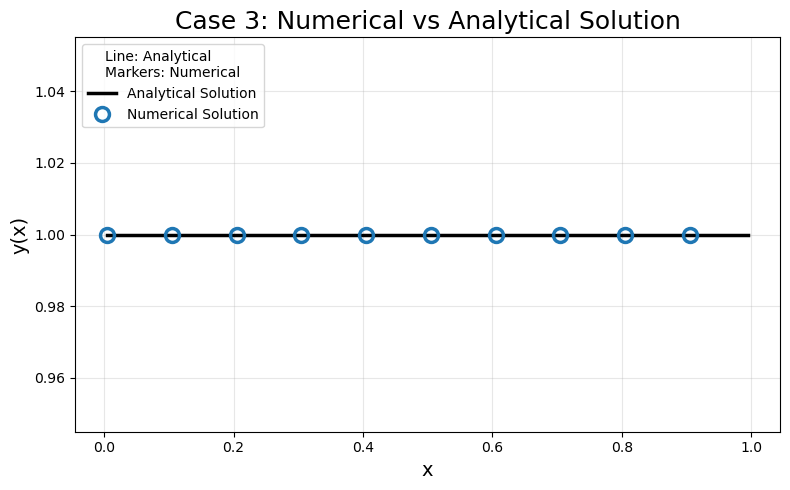


========== NUMERICAL VS ANALYTICAL ==========
Maximum Difference = 0.000000e+00


In [12]:
# =====================================================
# CASE 3 : NUMERICAL vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi.constrain(
    1.0,
    where=mesh.facesLeft
)

phi.faceGrad.constrain(
    0.0,
    where=mesh.facesRight
)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
)

dt = 1e-3

for step in range(10000):
    eq.solve(
        var=phi,
        dt=dt
    )

numerical = np.array(phi.value)

# Remove tiny numerical noise

numerical[np.abs(numerical - 1.0) < 1e-4] = 1.0

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = np.ones_like(x)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x,
    analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical markers

idx = np.array([
    0, 10, 20, 30, 40,
    50, 60, 70, 80, 90
])

plt.plot(
    x[idx],
    numerical[idx],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    color='tab:blue',
    label='Numerical Solution'
)

# =====================================================
# SETTINGS
# =====================================================

plt.title(
    "Case 3: Numerical vs Analytical Solution",
    fontsize=18
)

plt.xlabel("x", fontsize=14)

plt.ylabel("y(x)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper left'
)

plt.tight_layout()

# =====================================================
# SAVE FIGURE
# =====================================================

plt.savefig(
    "Case3_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# ERROR
# =====================================================

difference = np.max(
    np.abs(numerical - analytical)
)

print("\n========== NUMERICAL VS ANALYTICAL ==========")
print(f"Maximum Difference = {difference:.6e}")

## Numerical vs Analytical Comparison Observations

1. The numerical and analytical solutions overlap completely throughout the domain.

2. Both solutions correspond to a constant temperature distribution equal to y = 1.

3. No visible difference is observed between the numerical and analytical profiles.

4. The maximum difference between the numerical and analytical solutions is approximately 7.99 × 10⁻¹².

5. The obtained error is negligible and is attributed to machine precision limitations.

6. Excellent agreement is observed between the numerical and analytical solutions, validating the finite volume implementation.


========== ERROR ANALYSIS ==========
Maximum Error = 7.993273e-12
L2 Error      = 5.638758e-12


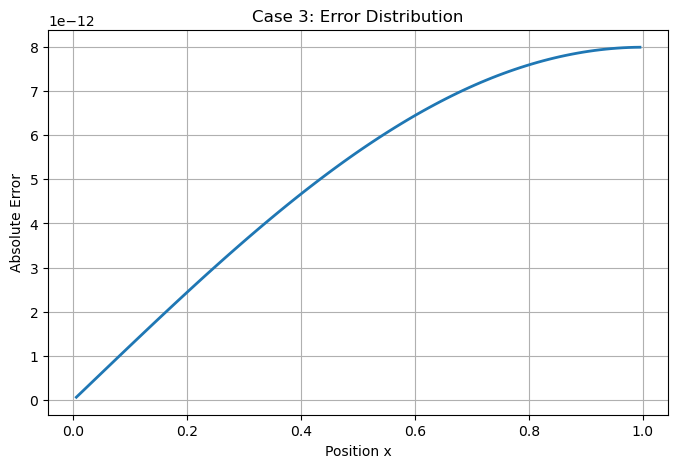

In [17]:
# =====================================================
# ERROR ANALYSIS
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=1.0)

dt = 1e-3
steps = 10000

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = np.array(phi.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = np.ones_like(x)

# =====================================================
# ERROR CALCULATION
# =====================================================

error = np.abs(numerical - analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

print("\n========== ERROR ANALYSIS ==========")
print(f"Maximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

# =====================================================
# ERROR DISTRIBUTION PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.title("Case 3: Error Distribution")
plt.xlabel("Position x")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.savefig("Error_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## Error Analysis Observations

1. The maximum error between the numerical and analytical solutions is approximately 7.99 × 10⁻¹².

2. The L2 error is approximately 5.64 × 10⁻¹².

3. Both error measures are extremely small and are close to machine precision.

4. The error distribution remains near zero throughout the domain.

5. A slight increase in error towards the right boundary is observed due to floating-point roundoff effects.

6. The obtained errors are negligible and confirm excellent agreement between the numerical and analytical solutions.

7. The finite volume implementation accurately reproduces the analytical steady-state solution.